# Занятие 1. Лабораторная: kNN своими руками

Пять задач и два бонуса. Задачи с первой по пятую — основная часть, за нее
ставится балл. Бонусы для тех, кто закончил раньше.

На семинаре мы пользовались готовыми моделями из scikit-learn. Здесь пишем
то же самое руками: не ради страданий, а потому что метод, который вы
написали сами, потом не получится применить не подумав. В конце каждой
задачи есть сверка с библиотечной реализацией — должно совпасть.

За каждой задачей идет ячейка с проверками. Запустите ее: если она отработала
и напечатала, что все в порядке, задача решена и можно идти дальше.
Если упала — читайте текст ошибки, там написано, что именно не сошлось.

Работать можно в одиночку или вдвоем. Спрашивать меня можно и нужно:
за вопросы балл не снижается.

**Что показать в конце пары.** Запущенный ноутбук: все проверки зеленые,
на вопросы в текстовых ячейках даны ответы. Не успели — дорешайте дома
и покажите на следующем занятии, балл засчитается.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42

wine = load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.3, random_state=SEED, stratify=wine.target
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("train:", X_train.shape, " test:", X_test.shape)

train: (124, 13)  test: (54, 13)


## Задача 1. Считаем расстояния сами

На семинаре kNN работал через scikit-learn: мы создавали объект, звали `fit`
и `predict`, а что происходит внутри, оставалось за кадром. Здесь мы этот
кадр раскроем — напишем метод руками и убедимся, что получается то же самое.

Начнем с расстояний. Евклидово вы знаете:

$$\rho(a, b) = \sqrt{\sum_{j=1}^{d} (a_j - b_j)^2}$$

Нужна матрица расстояний: от каждого объекта запроса до каждого обучающего.
Циклом это писать долго и медленно, поэтому используем **broadcasting**.
Если превратить массивы формы `(m, d)` и `(n, d)` в `(m, 1, d)` и `(1, n, d)`,
то при вычитании numpy растянет единичные оси и вернет `(m, n, d)` — все
попарные разности сразу. Дальше возвести в квадрат, просуммировать
по последней оси и взять корень.

Добавить ось можно через `None` в индексации: `A[:, None, :]` дает `(m, 1, d)`.

Евклидово расстояние не единственное.

**Манхэттенское** — сумма модулей разностей по координатам. Названо
в честь сетки улиц: пройти по диагонали нельзя, только вдоль кварталов.

$$\rho_1(a, b) = \sum_{j=1}^{d} |a_j - b_j|$$

**Косинусное** — измеряет угол между векторами, а не расстояние между
их концами. Длина векторов при этом не важна.

$$\rho_{\cos}(a, b) = 1 - \frac{\langle a, b \rangle}{\|a\| \cdot \|b\|}$$

Реализуйте все три метрики и сам метод ближайших соседей: посчитать
расстояния, взять `k` ближайших через `np.argsort`, вернуть самый частый
класс среди них.

In [2]:
def euclidean(A, B):
    A = A[:, None, :]
    B = B[None, :, :]
    diff = A - B
    return np.sqrt(np.sum(diff*diff, axis=-1))


def manhattan(A, B):
    A = A[:, None, :]
    B = B[None, :, :]
    diff = A - B
    return np.sum(np.abs(diff), axis=-1)


def cosine(A, B):
    A_norm = np.sqrt(np.sum(A*A, axis=1))
    B_norm = np.sqrt(np.sum(B*B, axis=1))
    return 1 - A@B.T/(A_norm[:, None]*B_norm[None, :])


def knn_predict(X_train, y_train, X_query, k=5, distance=euclidean):
    d = distance(X_query, X_train)
    nearest = np.argsort(d, axis=1)[:, :k]
    labels = y_train[nearest]

    n_classes = y_train.max() + 1
    votes = np.array([np.bincount(s, minlength=n_classes) for s in labels])
    return np.argmax(votes, axis=1)


for name, fn in [("евклидово", euclidean), ("манхэттен", manhattan), ("косинус", cosine)]:
    pred = knn_predict(X_train_s, y_train, X_test_s, k=5, distance=fn)
    print(f"{name:12s} accuracy = {accuracy_score(y_test, pred):.3f}")

евклидово    accuracy = 0.944
манхэттен    accuracy = 0.981
косинус      accuracy = 0.963


In [3]:
# --- проверка ---
from sklearn.metrics.pairwise import (
    cosine_distances, euclidean_distances, manhattan_distances,
)

a = np.array([[0.0, 0.0], [3.0, 4.0]])
b = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])

# 1. формы результата
assert manhattan(a, b).shape == (2, 3), "манхэттен вернул не ту форму"
assert cosine(a, b).shape == (2, 3), "косинус вернул не ту форму"

# 2. манхэттенское расстояние от (3,4) до начала координат равно 3 + 4
assert np.isclose(manhattan(a, b)[1, 0], 7.0), "манхэттен посчитан неверно"

# 3. косинусное расстояние между ортогональными векторами равно единице
assert np.isclose(cosine(np.array([[1.0, 0.0]]), np.array([[0.0, 1.0]]))[0, 0], 1.0), \
    "для ортогональных векторов косинусное расстояние должно быть 1"

# 4. а между сонаправленными — нулю, независимо от длины
assert np.isclose(cosine(np.array([[1.0, 1.0]]), np.array([[5.0, 5.0]]))[0, 0], 0.0), \
    "косинусное расстояние не должно зависеть от длины вектора"

# 5. сверка всех трех с реализациями scikit-learn
assert np.allclose(euclidean(X_test_s, X_train_s), euclidean_distances(X_test_s, X_train_s))
assert np.allclose(manhattan(X_test_s, X_train_s), manhattan_distances(X_test_s, X_train_s))
assert np.allclose(cosine(X_test_s, X_train_s), cosine_distances(X_test_s, X_train_s), atol=1e-8)

# 6. kNN с параметром distance ведет себя разумно
assert (knn_predict(X_train_s, y_train, X_train_s, k=1) == y_train).all(), \
    "при k=1 объект обязан предсказать сам себя"

print("проверки пройдены")

проверки пройдены


/tmp/ipykernel_6211/3207714998.py:18: RuntimeWarning: invalid value encountered in divide
  return 1 - A@B.T/(A_norm[:, None]*B_norm[None, :])


**Вопрос.** Какая метрика оказалась лучше и почему, как вам кажется?
Подсказка: подумайте, что теряет косинусное расстояние по сравнению
с евклидовым, и важна ли эта потеря именно на этих данных.

Ответ: Косинусное расстояние теряет информацию о длине вектора по факту. Лучшие результаты показало манхэттенское расстояние. Видимо, на этих данных масштаб векторов имел значение (у косинусного расстояния этот момент не учитывается, вот оно и просело). В отличие от евклидова, манхэттенское также не возводит различия по отдельным признакам в квадрат, поэтому меньше усиливает большие отклонения по отдельным координатам.

## Задача 2. Взвешенное голосование

В обычном kNN все соседи равноправны: ближайший и пятый по близости имеют
один голос. Логичнее давать более близким соседям больший вес.

Стандартный вариант — вес, обратный расстоянию:

$$w_i = \frac{1}{\rho_i + \varepsilon}$$

Маленькое $\varepsilon$ нужно, чтобы не делить на ноль, когда объект
совпал с обучающим. Класс выбирается по сумме весов, а не по числу голосов:

$$a(x) = \arg\max_{c} \sum_{i \in N_k(x)} w_i \cdot [y_i = c]$$

Реализуйте взвешенный вариант и сравните с обычным при разных `k`.

In [4]:
def knn_predict_weighted(X_train, y_train, X_query, k=5, eps=1e-9):
    d = euclidean(X_query, X_train)
    nearest = np.argsort(d, axis=1)[:, :k]

    rows = np.arange(len(X_query))[:, None]
    neighbor_d = d[rows, nearest]
    weights = 1 / (neighbor_d + eps)
    labels = y_train[nearest]

    n_classes = y_train.max() + 1
    scores = np.array([np.bincount(s, minlength=n_classes, weights=w) for s, w in zip(labels, weights)])
    return np.argmax(scores, axis=1)


k_values = [1, 3, 5, 9, 15, 25, 40]
plain, weighted = [], []

for k in k_values:
    plain.append(accuracy_score(y_test, knn_predict(X_train, y_train, X_test, k=k)))
    weighted.append(accuracy_score(y_test, knn_predict_weighted(X_train, y_train, X_test, k=k)))

print(pd.DataFrame({"k": k_values, "обычный": plain, "взвешенный": weighted}))

    k   обычный  взвешенный
0   1  0.703704    0.703704
1   3  0.685185    0.666667
2   5  0.722222    0.703704
3   9  0.722222    0.722222
4  15  0.722222    0.740741
5  25  0.740741    0.685185
6  40  0.703704    0.722222


In [5]:
# --- проверка ---

# 1. по значению на каждое k
assert len(plain) == len(weighted) == len(k_values), "не совпала длина списков"

# 2. при k=1 взвешивание ничего не меняет: сосед всего один
assert np.array_equal(
    knn_predict(X_train_s, y_train, X_test_s, k=1),
    knn_predict_weighted(X_train_s, y_train, X_test_s, k=1),
), "при k=1 оба варианта обязаны совпадать"

# 3. предсказанные метки корректны
pred_w = knn_predict_weighted(X_train_s, y_train, X_test_s, k=5)
assert pred_w.shape == y_test.shape, "не то число предсказаний"
assert set(np.unique(pred_w)) <= set(np.unique(y_train)), "предсказан несуществующий класс"

# 4. взвешенный вариант совпадает со sklearn при weights="distance"
sk = KNeighborsClassifier(n_neighbors=5, weights="distance").fit(X_train_s, y_train)
agreement = (sk.predict(X_test_s) == pred_w).mean()
assert agreement > 0.95, f"расхождение со sklearn слишком велико: совпало {agreement:.2f}"

# 5. при большом k взвешивание уже не вырождается в константу
assert len(np.unique(knn_predict_weighted(X_train_s, y_train, X_test_s, k=len(X_train_s)))) > 1, \
    "взвешенный kNN при k=n не должен схлопываться в один класс"

print(f"проверки пройдены, совпадение со sklearn {agreement:.3f}")

проверки пройдены, совпадение со sklearn 1.000


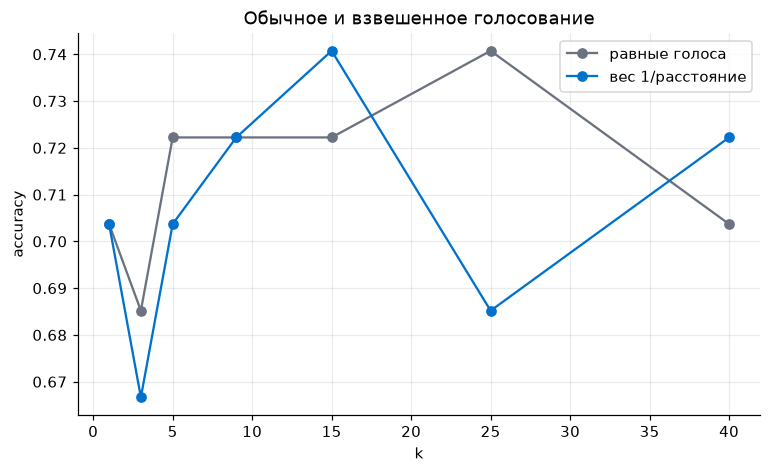

In [6]:
fig, ax = plt.subplots()
ax.plot(k_values, plain, "o-", label="равные голоса", color="#6B7280")
ax.plot(k_values, weighted, "o-", label="вес 1/расстояние", color="#0072CE")
ax.set_xlabel("k")
ax.set_ylabel("accuracy")
ax.set_title("Обычное и взвешенное голосование")
ax.legend()
plt.show()

**Вопрос.** При каких `k` взвешивание дает выигрыш, а при каких разницы нет?
Отдельно объясните пятую проверку: почему обычный kNN при `k = n` выдает
константу, а взвешенный нет.

Ответ: При k=15, k=40 взвешивание дает выигрыш. При k=1, k=9 разницы нет. При k=3, k=5 и k=25 обычный knn лучше. 
5-ая проверка: обычный knn при k=n не смотрит на геометрическое расположение данных, а смотрит только, какого класса в train больше, однако
взвешенный knn это учитывает, потому что расстояния всё ещё влияют через веса.

## Задача 3. Способ масштабирования

`StandardScaler` вычитает среднее и делит на стандартное отклонение:

$$z = \frac{x - \mu}{\sigma}$$

`MinMaxScaler` линейно сжимает каждый признак в отрезок от нуля до единицы:

$$z = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Сравните три варианта: без масштабирования, `StandardScaler`, `MinMaxScaler`.
Постройте зависимость accuracy от `k` для всех трех на одних осях
и сложите результаты в словарь `curves`.

In [7]:
mm = MinMaxScaler()
k_grid = list(range(1, 31))
curves = {}

X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)

variants = {
    "без масштабирования": (X_train, X_test),
    "StandardScaler": (X_train_s, X_test_s),
    "MinMaxScaler": (X_train_mm, X_test_mm),
}

for name, (tr, te) in variants.items():
    curves[name] = [accuracy_score(y_test, knn_predict(tr, y_train, te, k=k)) for k in k_grid]
    print(f"{name:22s} лучшее {max(curves[name]):.3f}")

без масштабирования    лучшее 0.741
StandardScaler         лучшее 1.000
MinMaxScaler           лучшее 1.000


In [8]:
# --- проверка ---

# 1. посчитаны все три варианта
assert set(curves) == {"без масштабирования", "StandardScaler", "MinMaxScaler"}, \
    "не хватает какого-то из трех вариантов"

# 2. в каждой кривой по значению на каждое k
assert all(len(v) == len(k_grid) for v in curves.values()), "не совпала длина кривых"

# 3. MinMaxScaler действительно уложил обучающие данные в отрезок [0, 1]
assert X_train_mm.min() >= -1e-9 and X_train_mm.max() <= 1 + 1e-9, \
    "MinMaxScaler должен приводить трейн к отрезку [0, 1]"

# 4. масштабирование выигрывает у его отсутствия при любом разумном k
best_raw = max(curves["без масштабирования"])
best_std = max(curves["StandardScaler"])
assert best_std > best_raw, "стандартизация не дала выигрыша"

# 5. и этот выигрыш больше, чем разброс по k внутри одного варианта
spread_std = max(curves["StandardScaler"]) - min(curves["StandardScaler"])
gain = best_std - best_raw
assert gain > spread_std, "ожидали, что выбор масштабирования важнее выбора k"

print(f"проверки пройдены: выигрыш от масштабирования {gain:.3f}, "
      f"разброс по k внутри StandardScaler {spread_std:.3f}")

проверки пройдены: выигрыш от масштабирования 0.259, разброс по k внутри StandardScaler 0.074


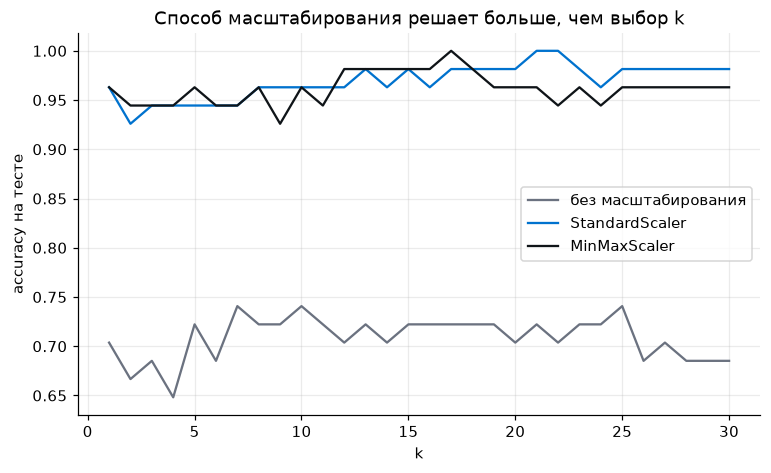

In [9]:
colors = {"без масштабирования": "#6B7280",
          "StandardScaler": "#0072CE",
          "MinMaxScaler": "#0F1418"}

fig, ax = plt.subplots()
for name, values in curves.items():
    ax.plot(k_grid, values, label=name, color=colors[name])
ax.set_xlabel("k")
ax.set_ylabel("accuracy на тесте")
ax.set_title("Способ масштабирования решает больше, чем выбор k")
ax.legend()
plt.show()

**Вопрос.** Пятая проверка формализует главный вывод задачи. Сформулируйте
его словами: что надо делать в первую очередь, когда качество модели
не устраивает.

Ответ: Если качество knn не устраивает, сначала стоит проверить масштабирование признаков, а потом подбирать k. В этой задаче выбор способа масштабирования дал заметно больший прирост качества, чем изменение числа соседей.

## Задача 4. Проклятие размерности

Сейчас вы увидите, как kNN ломается. Это его главная слабость,
и знать о ней надо до того, как наступишь.

Добавьте к данным шумовые признаки — колонки со случайными числами,
не имеющие никакого отношения к целевой переменной. Начните с пяти,
доведите до восьмисот. Масштабируйте все вместе и стройте график.

Результаты сложите в список `scores` в том же порядке, что и `noise_counts`.

In [10]:
rng = np.random.default_rng(SEED)
noise_counts = [0, 5, 10, 25, 50, 100, 200, 400, 800]
scores = []

for n_noise in noise_counts:
    if n_noise:
        tr = np.concatenate([X_train, rng.normal(size=(X_train.shape[0], n_noise))], axis=1)
        te = np.concatenate([X_test, rng.normal(size=(X_test.shape[0], n_noise))], axis=1)
    else:
        tr, te = X_train, X_test

    sc = StandardScaler()
    tr_s = sc.fit_transform(tr)
    te_s = sc.transform(te)

    scores.append(accuracy_score(y_test, knn_predict(tr_s, y_train, te_s)))

for n, value in zip(noise_counts, scores):
    print(f"  +{n:4d} шумовых признаков -> accuracy {value:.3f}")

  +   0 шумовых признаков -> accuracy 0.944
  +   5 шумовых признаков -> accuracy 0.926
  +  10 шумовых признаков -> accuracy 0.926
  +  25 шумовых признаков -> accuracy 0.889
  +  50 шумовых признаков -> accuracy 0.926
  + 100 шумовых признаков -> accuracy 0.704
  + 200 шумовых признаков -> accuracy 0.759
  + 400 шумовых признаков -> accuracy 0.556
  + 800 шумовых признаков -> accuracy 0.463


In [11]:
# --- проверка ---

# 1. по значению на каждый уровень шума
assert len(scores) == len(noise_counts), "не совпала длина списка результатов"

# 2. все значения это доли
assert all(0.0 <= s <= 1.0 for s in scores), "accuracy вне отрезка [0, 1]"

# 3. без шума результат такой же, как у обычного kNN на этих данных
reference = KNeighborsClassifier(5).fit(X_train_s, y_train).score(X_test_s, y_test)
assert np.isclose(scores[0], reference), "нулевой уровень шума должен совпадать с базовым результатом"

# 4. восемьсот шумовых признаков заметно ломают метод
assert scores[-1] < scores[0] - 0.2, "ожидали существенное падение качества от шума"

# 5. и в пределе метод скатывается к чему-то близкому к угадыванию
assert scores[-1] < 0.6, "при 800 шумовых признаках kNN должен работать плохо"

print(f"проверки пройдены: {scores[0]:.3f} без шума -> {scores[-1]:.3f} с 800 шумовыми")

проверки пройдены: 0.944 без шума -> 0.463 с 800 шумовыми


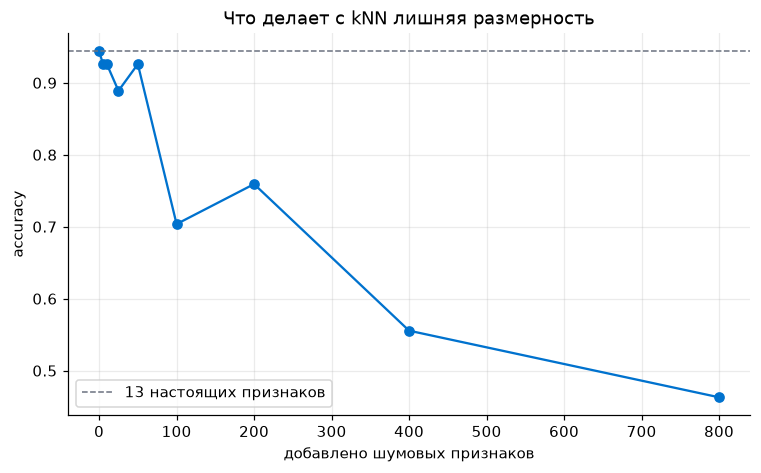

In [12]:
fig, ax = plt.subplots()
ax.plot(noise_counts, scores, "o-", color="#0072CE")
ax.axhline(scores[0], ls="--", color="#6B7280", lw=1, label="13 настоящих признаков")
ax.set_xlabel("добавлено шумовых признаков")
ax.set_ylabel("accuracy")
ax.set_title("Что делает с kNN лишняя размерность")
ax.legend()
plt.show()

### Что происходит с другим методом

Тот же эксперимент, но рядом с kNN считается наивный Байес. Код готовый.

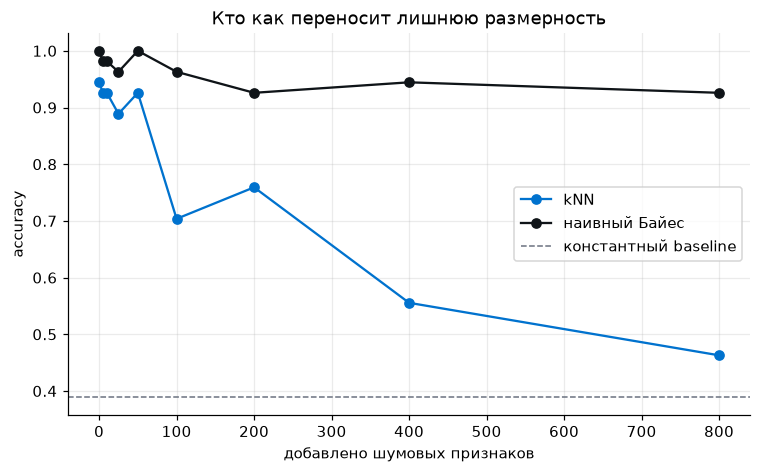

kNN:           0.944 -> 0.463
наивный Байес: 1.000 -> 0.926


In [13]:
from sklearn.naive_bayes import GaussianNB

rng = np.random.default_rng(SEED)
knn_scores, nb_scores = [], []

for n_noise in noise_counts:
    if n_noise:
        tr = np.hstack([X_train, rng.normal(size=(len(X_train), n_noise))])
        te = np.hstack([X_test, rng.normal(size=(len(X_test), n_noise))])
    else:
        tr, te = X_train, X_test

    sc = StandardScaler()
    tr_s, te_s = sc.fit_transform(tr), sc.transform(te)
    knn_scores.append(KNeighborsClassifier(5).fit(tr_s, y_train).score(te_s, y_test))
    nb_scores.append(GaussianNB().fit(tr_s, y_train).score(te_s, y_test))

fig, ax = plt.subplots()
ax.plot(noise_counts, knn_scores, "o-", color="#0072CE", label="kNN")
ax.plot(noise_counts, nb_scores, "o-", color="#0F1418", label="наивный Байес")
ax.axhline(np.bincount(y_test).max() / len(y_test), ls="--", color="#6B7280",
           lw=1, label="константный baseline")
ax.set_xlabel("добавлено шумовых признаков")
ax.set_ylabel("accuracy")
ax.set_title("Кто как переносит лишнюю размерность")
ax.legend()
plt.show()

print(f"kNN:           {knn_scores[0]:.3f} -> {knn_scores[-1]:.3f}")
print(f"наивный Байес: {nb_scores[0]:.3f} -> {nb_scores[-1]:.3f}")

**Вопрос.** Объясните механику происходящего. Посмотрите на формулу
евклидова расстояния и подумайте, какую долю в сумме занимают тринадцать
настоящих признаков, когда рядом лежит восемьсот шумовых.

Второй вопрос: почему наивный Байес держится заметно лучше? Подсказка:
он не считает расстояний, а перемножает по множителю на признак.
Что дает шумовой признак, распределение которого одинаково во всех классах?

*Ответ пишите здесь.*

## Задача 5. Своя матрица ошибок

Не используя `sklearn.metrics`, напишите функции, которые по двум векторам —
истинным и предсказанным меткам — считают матрицу ошибок, precision и recall
для бинарной задачи.

$$\text{precision} = \frac{TP}{TP + FP}, \qquad
  \text{recall} = \frac{TP}{TP + FN}, \qquad
  F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}
             {\text{precision} + \text{recall}}$$

Проверьте на датасете про опухоли.

In [14]:
cancer = load_breast_cancer()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=SEED, stratify=cancer.target
)
sc = StandardScaler()
Xc_tr_s, Xc_te_s = sc.fit_transform(Xc_tr), sc.transform(Xc_te)
yc_pred = KNeighborsClassifier(5).fit(Xc_tr_s, yc_tr).predict(Xc_te_s)


def confusion(y_true, y_pred):
    tp = np.sum((y_true == 1)&(y_pred == 1))
    tn = np.sum((y_true == 0)&(y_pred == 0))
    fp = np.sum((y_true == 0)&(y_pred == 1))
    fn = np.sum((y_true == 1)&(y_pred == 0))
    return tp, tn, fp, fn


def precision_recall(y_true, y_pred):
    tp, tn, fp, fn = confusion(y_true, y_pred)
    precision = tp / (tp + fp) if tp + fp != 0 else 0.0
    recall = tp / (tp + fn)  if tp + fn != 0 else 0.0
    return precision, recall


tp, tn, fp, fn = confusion(yc_te, yc_pred)
print(f"TP={tp}  FP={fp}")
print(f"FN={fn}  TN={tn}")

p, r = precision_recall(yc_te, yc_pred)
print(f"\nprecision = {p:.3f}")
print(f"recall    = {r:.3f}")

TP=107  FP=7
FN=0  TN=57

precision = 0.939
recall    = 1.000


In [15]:
# --- проверка ---
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# 1. четыре клетки в сумме дают число объектов
tp, tn, fp, fn = confusion(yc_te, yc_pred)
assert tp + tn + fp + fn == len(yc_te), "в матрицу попали не все объекты"

# 2. сходится с матрицей из scikit-learn
sk_tn, sk_fp, sk_fn, sk_tp = confusion_matrix(yc_te, yc_pred).ravel()
assert (tp, tn, fp, fn) == (sk_tp, sk_tn, sk_fp, sk_fn), "матрица ошибок не сошлась со sklearn"

# 3. precision и recall сходятся с библиотечными
p, r = precision_recall(yc_te, yc_pred)
assert np.isclose(p, precision_score(yc_te, yc_pred)), "precision не сошелся"
assert np.isclose(r, recall_score(yc_te, yc_pred)), "recall не сошелся"

# 4. f1 из ваших чисел сходится с библиотечным
assert np.isclose(2 * p * r / (p + r), f1_score(yc_te, yc_pred)), "f1 не сошелся"

# 5. функции не ломаются на вырожденном случае: модель никого не назвала единицей
zeros = np.zeros_like(yc_te)
p0, r0 = precision_recall(yc_te, zeros)
assert p0 == 0.0 and r0 == 0.0, "на пустых предсказаниях ожидали нули, а не деление на ноль"

print(f"проверки пройдены: precision={p:.3f}, recall={r:.3f}")

проверки пройдены: precision=0.939, recall=1.000


**Вопрос.** В этом датасете класс 1 означает доброкачественную опухоль,
то есть «здоров». Значит пропуск болезни — это когда модель сказала 1,
а на самом деле 0. Посмотрите, в какую клетку матрицы это попадает,
сколько таких случаев у вашей модели, и какую метрику надо максимизировать,
чтобы их стало меньше.

*Ответ пишите здесь.*

## Бонус 1. Наивный Байес своими руками

### Что нужно реализовать

Решающее правило метода:

$$a(x) = \arg\max_{c} \; P(y = c) \prod_{j=1}^{d} P(x_j \mid y = c)$$

Для числовых признаков берем нормальное распределение внутри каждого класса:

$$P(x_j \mid y = c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}}
  \exp\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)$$

Все обучение — это три набора чисел, посчитанных по обучающей выборке:

$$\hat{P}(y = c) = \frac{n_c}{n}, \qquad
  \hat{\mu}_{cj} = \frac{1}{n_c}\sum_{i:\, y_i = c} x_{ij}, \qquad
  \hat{\sigma}^2_{cj} = \frac{1}{n_c}\sum_{i:\, y_i = c}(x_{ij} - \hat{\mu}_{cj})^2$$

### Что означает это произведение

Прежде чем писать код, стоит понять, что именно вы собираетесь считать.

Перемножив $d$ одномерных нормальных плотностей по разным координатам,
получаем

$$P(x \mid y = c) = \frac{1}{(2\pi)^{d/2}
  \left(\prod_j \sigma_{cj}^2\right)^{1/2}}
  \exp\left(-\frac{1}{2}\sum_{j=1}^{d}
  \frac{(x_j - \mu_{cj})^2}{\sigma_{cj}^2}\right)$$

Это многомерное нормальное распределение с вектором средних $\mu_c$
и **диагональной** ковариационной матрицей
$\Sigma_c = \mathrm{diag}(\sigma_{c1}^2, \dots, \sigma_{cd}^2)$.

Другими словами, ваша модель описывает каждый класс одним нормальным
облаком, вытянутым вдоль осей координат. Нули вне диагонали — это и есть
наивное предположение: связи между признаками объявлены отсутствующими.

Отсюда сразу понятно, что считать в `fit`: вектор средних и вектор
дисперсий на каждый класс, ровно по формулам выше. Никаких ковариаций
считать не нужно, они по построению нули.

### Почему логарифмы

Считать произведение тринадцати плотностей напрямую нельзя. Каждая
из них меньше единицы, произведение получается порядка $10^{-30}$,
и на таких числах теряется точность: результат превращается в ноль.

Логарифм переводит произведение в сумму и снимает проблему.
Максимум при этом не сдвигается, потому что логарифм монотонно возрастает:

$$\log\left[P(y = c) \prod_j P(x_j \mid y = c)\right]
 = \log P(y = c) + \sum_{j=1}^{d} \log P(x_j \mid y = c)$$

Подставив нормальную плотность, получаем то, что и надо запрограммировать:

$$\log P(y = c \mid x) = \log P(y = c)
  - \frac{1}{2} \sum_{j=1}^{d}
    \left[ \log\left(2\pi\sigma_{cj}^2\right)
          + \frac{(x_j - \mu_{cj})^2}{\sigma_{cj}^2} \right] + \text{const}$$

Константа одна для всех классов, поэтому ее можно не считать.

Маленькая деталь: к дисперсии стоит прибавить крошечное число вроде $10^{-9}$.
Если признак внутри класса принимает одно и то же значение, дисперсия
окажется нулевой, и деление развалится.

В scikit-learn эта добавка называется `var_smoothing` и устроена чуть умнее:
прибавляется не абсолютная величина, а $10^{-9}$ от самой большой дисперсии
среди всех признаков, и лежит в атрибуте `epsilon_`. Поэтому ваши дисперсии
совпадут с библиотечными не напрямую, а только после того, как из обеих
вычесть их сглаживание. Предсказания при этом совпадут полностью.

In [16]:
class MyGaussianNB:
    def fit(self, X, y):
        eps = 1e-9
        self.classes_ = np.unique(y)
        self.prior_ = np.array([np.mean(y == c) for c in self.classes_])
        self.mean_ = np.array([np.mean(X[y == c], axis=0) for c in self.classes_])
        self.var_ = np.array([np.var(X[y == c], axis=0) + eps for c in self.classes_])
        return self

    def log_proba(self, X):
        out = np.zeros((len(X), len(self.classes_)))
        for i in range(len(self.classes_)):
            log_density = -0.5 * (np.log(2 * np.pi * self.var_[i]) + (X - self.mean_[i]) ** 2 / self.var_[i])
            out[:, i] = np.log(self.prior_[i]) + np.sum(log_density, axis=1)
        return out

    def predict(self, X):
        return self.classes_[np.argmax(self.log_proba(X), axis=1)]


from sklearn.naive_bayes import GaussianNB

mine = MyGaussianNB().fit(X_train, y_train)
theirs = GaussianNB().fit(X_train, y_train)

In [17]:
# --- проверка ---

# 1. формы выученных таблиц: класс на признак
assert mine.mean_.shape == (3, X_train.shape[1]), "не та форма таблицы средних"
assert mine.var_.shape == (3, X_train.shape[1]), "не та форма таблицы дисперсий"

# 2. априорные вероятности классов в сумме дают единицу
assert np.isclose(mine.prior_.sum(), 1.0), "априорные вероятности не суммируются в единицу"

# 3. средние совпадают с тем, что выучил sklearn, до последнего знака
assert np.allclose(mine.mean_, theirs.theta_), "средние не сошлись со sklearn"

# и дисперсии совпадают после того, как из обеих вычесть сглаживание:
# вы прибавили абсолютное 1e-9, а sklearn прибавляет theirs.epsilon_
assert np.allclose(mine.var_ - 1e-9, theirs.var_ - theirs.epsilon_),     "дисперсии не сошлись со sklearn"

# 4. и предсказания тоже совпадают, объект в объект
assert np.array_equal(mine.predict(X_test), theirs.predict(X_test)), \
    "предсказания разошлись со sklearn"

# 5. логарифмы вероятностей конечны, переполнения не случилось
lp = mine.log_proba(X_test)
assert np.isfinite(lp).all(), "в логарифмах появились inf или nan"

# 6. то же самое можно посчитать через готовую многомерную нормаль
#    с диагональной ковариацией: если ваша реализация верна, совпадет
from scipy.stats import multivariate_normal

c = 0
reference = multivariate_normal(
    mean=mine.mean_[c], cov=np.diag(mine.var_[c])
).logpdf(X_test) + np.log(mine.prior_[c])
assert np.allclose(lp[:, c], reference), (
    "ваши логарифмы разошлись с многомерной нормалью, у которой на диагонали "
    "стоят те же дисперсии; проверьте, не потеряли ли множитель или априорную "
    "вероятность класса"
)

print("проверки пройдены, наш наивный Байес неотличим от библиотечного")

проверки пройдены, наш наивный Байес неотличим от библиотечного


## Бонус 2. Где проходит граница

Возьмите два признака из датасета про вино, обучите на них kNN и нарисуйте
границу решений: раскрасьте плоскость по тому, какой класс предсказывает
модель в каждой точке.

Сделайте это для `k = 1`, `k = 5` и `k = 50`. Это самая наглядная
иллюстрация переобучения из всех, что есть в курсе.

In [18]:
pair = [wine.feature_names.index("flavanoids"), wine.feature_names.index("color_intensity")]
boundary = {}

sc2 = StandardScaler()
X2_tr = ...
X2_te = ...

xx, yy = np.meshgrid(..., ...)
grid = np.c_[xx.ravel(), yy.ravel()]

for k in (1, 5, 50):
    model = ...
    zz = ...
    boundary[k] = (zz, ..., ...)

In [19]:
# --- проверка ---

# 1. посчитаны все три значения k
assert set(boundary) == {1, 5, 50}, "не хватает какого-то значения k"

# 2. предсказания на сетке имеют форму сетки и содержат только настоящие классы
for k, (zz, tr_acc, te_acc) in boundary.items():
    assert zz.shape == (300, 300), f"для k={k} не та форма сетки"
    assert set(np.unique(zz)) <= {0, 1, 2}, f"для k={k} предсказан несуществующий класс"

# 3. при k=1 модель безошибочна на обучающей выборке
assert np.isclose(boundary[1][1], 1.0), "при k=1 train accuracy обязана быть равна 1"

# 4. а при k=50 уже нет: граница слишком грубая
assert boundary[50][1] < 1.0, "при k=50 модель не может быть идеальной на трейне"

# 5. двух признаков хватает хуже, чем всех тринадцати
full = KNeighborsClassifier(5).fit(X_train_s, y_train).score(X_test_s, y_test)
assert boundary[5][2] <= full, "два признака не могут быть лучше всех тринадцати"

print("проверки пройдены")
for k, (_, tr_acc, te_acc) in boundary.items():
    print(f"  k={k:2d}   train {tr_acc:.3f}   test {te_acc:.3f}")

AttributeError: 'ellipsis' object has no attribute 'shape'

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, k in zip(axes, [1, 5, 50]):
    zz, train_acc, test_acc = boundary[k]
    ax.contourf(xx, yy, zz, alpha=0.22, cmap="coolwarm")
    ax.scatter(X2_tr[:, 0], X2_tr[:, 1], c=y_train, cmap="coolwarm",
               edgecolor="white", s=35, linewidth=0.6)
    ax.set_title(f"k = {k}   train {train_acc:.2f}   test {test_acc:.2f}")
    ax.set_xlabel("flavanoids")
    ax.grid(False)
axes[0].set_ylabel("color_intensity")
plt.tight_layout()
plt.show()

**Вопрос.** Опишите словами, чем отличаются три картинки. Какая граница
выглядит «правильнее» и почему это ощущение может обманывать. Соотнесите
это с числами, которые напечатала проверка.

*Ответ пишите здесь.*

## Итог

Проверьте себя. После этой лабораторной вы должны уметь объяснить:

- почему масштабирование признаков для kNN важнее выбора `k`;
- что происходит с методом при росте числа признаков и почему;
- чем отличаются precision и recall и как выбрать между ними;
- почему при `k = 1` качество на обучающей выборке всегда равно единице;
- зачем в наивном Байесе считают логарифмы, а не сами вероятности

Если какой-то пункт вызывает затруднение, спросите сейчас, а не на зачете.